# Multi-layer Perceptron

## Perceptron

A binary perceptron is a linear threshold classifier:

$$
\hat y = \operatorname{sign}(w^\top x + b), \qquad x \in \mathbb{R}^d,\; w \in \mathbb{R}^d,\; b \in \mathbb{R}.
$$

Geometrically, the equation $w^\top x + b = 0$ defines a hyperplane. One side is labeled $+1$, the other $-1$. The model is therefore simple and interpretable, but it is limited to linearly separable data.

Given training pairs $(x_i, y_i)_{i=1}^N$ with $y_i \in \{-1, +1\}$, Rosenblatt's update changes the parameters only when a point is misclassified:

$$
\text{if } y_i (w^\top x_i + b) \le 0, \qquad
w \leftarrow w + \eta y_i x_i, \qquad b \leftarrow b + \eta y_i.
$$

The perceptron convergence theorem says that if the data are linearly separable, this mistake-driven update reaches a separating hyperplane after finitely many updates. What it cannot do is invent a curved or disconnected boundary when the geometry of the data demands one.

In [1]:
import numpy as np
from typing import Optional

class Perceptron:
    """Binary perceptron with sign activation and Rosenblatt updates (NumPy).
    
    Args:
        in_dim: int, number of input features.
        lr: float, learning rate for mistake-driven updates.
        random_state: Optional[int], optional RNG seed used only for shuffling.
    """
    def __init__(self, in_dim: int, lr: float = 0.1, random_state: Optional[int] = None):
        self.lr = float(lr)
        self.w = np.zeros(in_dim, dtype=float)
        self.b = 0.0
        self.rng = np.random.default_rng(random_state)

    def decision_function(self, X):
        """Return g(x) = w·x + b for X of shape (N,d) or (d,)."""
        X = np.asarray(X, dtype=float)
        return X @ self.w + self.b

    def predict(self, X):
        """Return labels in {-1, +1}."""
        g = self.decision_function(X)
        return np.where(g >= 0.0, 1, -1)

    def fit(self, X, y, epochs: int = 50, shuffle: bool = True):
        """Rosenblatt training loop. Returns list of mistakes per epoch."""
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        n = X.shape[0]
        idx = np.arange(n)

        history = []
        for _ in range(epochs):
            if shuffle:
                self.rng.shuffle(idx)
            mistakes = 0
            for i in idx:
                xi, yi = X[i], y[i]
                if yi * (xi @ self.w + self.b) <= 0.0:
                    self.w += self.lr * yi * xi
                    self.b += self.lr * yi
                    mistakes += 1
            history.append(mistakes)
            if mistakes == 0:
                break
        return history

## What One Perceptron Can and Cannot Learn

A single perceptron can represent Boolean rules such as AND and OR because those classes are separated by one line in the $(x_1, x_2)$ plane. XOR is different: the positive labels sit on opposite corners, so no single line can isolate them from the negative labels.

That geometric obstruction is the real reason multilayer networks matter. Once we compose several affine maps with nonlinear activations, we are no longer restricted to one separating hyperplane.

AND | final mistakes per epoch: [3, 3, 3, 1, 0]
     predictions: [-1, -1, -1, 1]
 OR | final mistakes per epoch: [2, 1, 3, 1, 0]
     predictions: [-1, 1, 1, 1]
XOR | final mistakes per epoch: [4, 4, 4, 4, 3]
     predictions: [1, 1, 1, 1]


/var/folders/5j/7wvtt6b90dl7r_nz2w93dwy00000gn/T/ipykernel_21477/1021100317.py:54: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x1, x2,


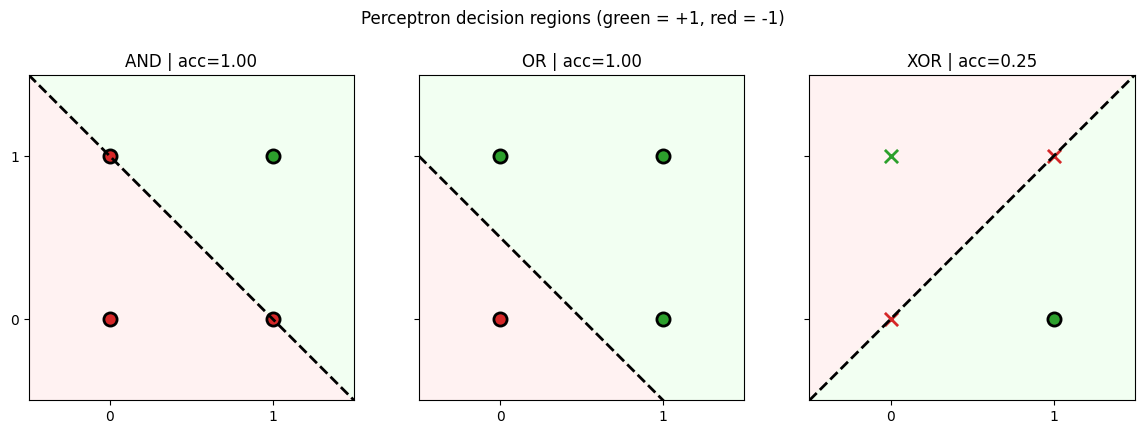

In [2]:
import numpy as np
import matplotlib.pyplot as plt

X_bool = np.array([[0.,0.],[0.,1.],[1.,0.],[1.,1.]], dtype=float)
y_AND  = np.array([-1, -1, -1, +1], dtype=int)  # AND: only (1,1) -> +1
y_OR   = np.array([-1, +1, +1, +1], dtype=int)  # OR : only (0,0) -> -1
y_XOR  = np.array([-1, +1, +1, -1], dtype=int)  # XOR: parity

# === Train & print results (NumPy Perceptron) ===
for name, y in [('AND', y_AND), ('OR', y_OR), ('XOR', y_XOR)]:
    clf = Perceptron(in_dim=2, lr=0.2)  # your NumPy perceptron class
    mistakes_per_epoch = clf.fit(X_bool, y, epochs=50)
    preds = clf.predict(X_bool).tolist()
    print(f"{name:>3} | final mistakes per epoch: {mistakes_per_epoch[-5:]}")
    print(f"     predictions: {preds}")

# === Plot decision regions for AND / OR / XOR (NumPy Perceptron) ===
def plot_boolean_perceptrons():
    datasets = [('AND', y_AND), ('OR', y_OR), ('XOR', y_XOR)]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

    for ax, (name, y) in zip(axes, datasets):
        clf = Perceptron(in_dim=2, lr=0.2)
        clf.fit(X_bool, y, epochs=100)

        # Background decision region
        xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                             np.linspace(-0.5, 1.5, 200))
        grid = np.c_[xx.ravel(), yy.ravel()]
        zz = clf.predict(grid).reshape(xx.shape)  # {-1,+1}
        ax.contourf(xx, yy, zz, levels=[-np.inf, 0, np.inf],
                    alpha=0.25, colors=['#ffcccc', '#ccffcc'])

        # Decision boundary line (w0 x + w1 y + b = 0)
        w = clf.w  # shape (2,)
        b = clf.b  # scalar
        if abs(w[1]) > 1e-10:
            xs = np.linspace(-0.5, 1.5, 200)
            ys = -(w[0]*xs + b)/w[1]
            ax.plot(xs, ys, 'k--', lw=2, label='decision boundary')
        else:
            # vertical boundary x = -b / w0
            if abs(w[0]) > 1e-12:
                x0 = -b / w[0]
                ax.axvline(x0, color='k', ls='--', lw=2, label='decision boundary')

        # Plot data points; "o" = correct, "×" = misclassified
        Xn = X_bool
        yn = y
        preds = clf.predict(X_bool)
        acc = (preds == yn).mean()
        for (x1, x2), yi, pi in zip(Xn, yn, preds):
            correct = (yi == pi)
            ax.scatter(x1, x2,
                       c='tab:green' if yi == 1 else 'tab:red',
                       s=90,
                       marker='o' if correct else 'x',
                       edgecolors='k',
                       linewidths=2)
        ax.set_title(f'{name} | acc={acc:.2f}')
        ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_aspect('equal', adjustable='box')

    fig.suptitle('Perceptron decision regions (green = +1, red = -1)', y=1.03, fontsize=12)
    plt.tight_layout()
    plt.show()

plot_boolean_perceptrons()

## From Perceptron to Multilayer Perceptron

An MLP keeps the same basic building block, an affine map followed by a nonlinearity, but stacks several of them. For hidden layers $\ell = 1, \dots, L-1$ we write

$$
a^{(0)} = x,
\qquad
z^{(\ell)} = W^{(\ell)} a^{(\ell-1)} + b^{(\ell)},
\qquad
a^{(\ell)} = \sigma\!\left(z^{(\ell)}\right),
$$

and for the final layer

$$
z^{(L)} = W^{(L)} a^{(L-1)} + b^{(L)}.
$$

For regression we may take the output to be $a^{(L)} = z^{(L)}$. For classification we usually interpret $z^{(L)}$ as logits and convert them into probabilities with softmax.

The important conceptual step is that each hidden layer re-expresses the data before the next linear separator acts. That is how a network made of simple pieces can represent nonlinear decision boundaries.

## Losses at the Output Layer

Training means choosing parameters that minimize an empirical loss over the dataset. For a mini-batch of size $B$, two common cases are enough for this notebook.

For regression with mean-squared error and identity output,

$$
\mathcal{L}_{\mathrm{MSE}} = \frac{1}{2B} \|A^{(L)} - Y\|_F^2,
\qquad
\frac{\partial \mathcal{L}}{\partial A^{(L)}} = \frac{1}{B} \left(A^{(L)} - Y\right).
$$

For multiclass classification with logits $Z^{(L)}$, softmax probabilities $P = \operatorname{softmax}(Z^{(L)})$, and one-hot targets $Y$,

$$
\mathcal{L}_{\mathrm{CE}} = -\frac{1}{B} \sum_{i=1}^B \sum_k Y_{ik} \log P_{ik},
$$

and the derivative with respect to the logits simplifies to

$$
\frac{\partial \mathcal{L}}{\partial Z^{(L)}} = \frac{1}{B} \left(P - Y\right).
$$

That cancellation is one of the reasons softmax with cross-entropy is so convenient in practice.

## Backpropagation

Backpropagation is just the chain rule applied efficiently from the output layer back to the input. Define the layer error

$$
\delta^{(\ell)} = \frac{\partial \mathcal{L}}{\partial z^{(\ell)}}.
$$

At the output layer, $\delta^{(L)}$ comes from the chosen loss. For hidden layers, the chain rule gives

$$
\delta^{(\ell)} = \left(\delta^{(\ell+1)} W^{(\ell+1)}\right) \odot \sigma'\!\left(z^{(\ell)}\right),
\qquad \ell = L-1, \dots, 1.
$$

Once the error signal is known, the parameter gradients are simple outer products and sums over the batch:

$$
\frac{\partial \mathcal{L}}{\partial W^{(\ell)}} = \left(\delta^{(\ell)}\right)^\top a^{(\ell-1)},
\qquad
\frac{\partial \mathcal{L}}{\partial b^{(\ell)}} = \sum_{i=1}^B \delta_i^{(\ell)}.
$$

Elementwise activation derivatives are equally compact: ReLU gives $\sigma'(z) = \mathbf{1}_{z>0}$, $\tanh$ gives $1 - \tanh^2(z)$, and the sigmoid gives $\sigma(z)\bigl(1-\sigma(z)\bigr)$.

A practical mini-batch training step therefore has four parts: forward pass, loss evaluation, backward pass, and parameter update. The code below keeps that structure explicit so the numerical experiments remain readable.

In [3]:
import numpy as np

# ---- utils ----
def count_params(model) -> int:
    return sum(W.size + b.size for W, b in zip(model.W, model.b))

def one_hot(y, n_classes):
    y = np.asarray(y, dtype=int).ravel()
    out = np.zeros((y.size, n_classes), dtype=float)
    out[np.arange(y.size), y] = 1.0
    return out

def softmax_logits(Z):
    Zs = Z - Z.max(axis=1, keepdims=True)
    expZ = np.exp(Zs)
    return expZ / np.clip(expZ.sum(axis=1, keepdims=True), 1e-12, None)

# ---- activations ----
def act_forward(Z, kind):
    if kind == 'relu':    return np.maximum(Z, 0.0)
    if kind == 'tanh':    return np.tanh(Z)
    if kind == 'sigmoid': return 1.0 / (1.0 + np.exp(-Z))
    if kind == 'identity':return Z
    raise ValueError(f"Unknown activation: {kind}")

def act_backward(Z, kind):
    if kind == 'relu':    return (Z > 0.0).astype(float)
    if kind == 'tanh':    T = np.tanh(Z); return 1.0 - T*T
    if kind == 'sigmoid':
        S = 1.0 / (1.0 + np.exp(-Z)); return S * (1.0 - S)
    if kind == 'identity':return np.ones_like(Z)
    raise ValueError(f"Unknown activation: {kind}")

# ---- initialisation ----
def init_linear(out_dim, in_dim, act='relu', rng=None):
    rng = rng or np.random.default_rng(None)
    if act == 'relu':
        std = np.sqrt(2.0 / in_dim)        # He
    else:
        std = np.sqrt(2.0 / (in_dim + out_dim))  # Glorot
    W = rng.normal(0.0, std, size=(out_dim, in_dim))
    b = np.zeros(out_dim, dtype=float)
    return W, b

class MLP:
    """
    NumPy MLP with manual backprop.
    Matches your torch signature: MLP(in_dim, out_dim, hidden_sizes, activation='relu')
    Hidden layers use 'activation'; output layer is linear (identity).
    """
    def __init__(self, in_dim, out_dim, hidden_sizes, activation='relu', seed=None):
        self.in_dim = int(in_dim)
        self.out_dim = int(out_dim)
        self.hidden = list(hidden_sizes)
        self.activation = activation
        self.rng = np.random.default_rng(seed)

        dims = [self.in_dim] + self.hidden + [self.out_dim]
        self.W, self.b = [], []
        for l in range(1, len(dims)):
            # init per previous activation (ReLU -> He; else Glorot)
            prev_act = activation if l < len(dims)-1 else 'identity'
            W, b = init_linear(dims[l], dims[l-1], act=('relu' if prev_act=='relu' else 'tanh'), rng=self.rng)
            self.W.append(W); self.b.append(b)

    # Forward returns activations & pre-activations for backprop
    def forward(self, X, cache=True):
        # X: (N, d_in)
        A = X
        As = [A]   # A0..AL
        Zs = []
        L = len(self.W)
        for l in range(L):
            Z = A @ self.W[l].T + self.b[l]           # (N, d_l)
            Zs.append(Z)
            if l < L-1:
                A = act_forward(Z, self.activation)    # hidden act
            else:
                A = Z                                  # identity at output
            As.append(A)
        return (A, (As, Zs)) if cache else (A, None)
    
    # Loss + first delta at output
    def loss_and_delta(self, A_L, Y, task='reg', weight_decay=0.0):
        N = A_L.shape[0]
        if task == 'reg':
            # Y: (N, out_dim); A_L: (N, out_dim)
            diff = A_L - Y
            loss = 0.5 * np.mean(diff*diff)
            dZ_L = diff / N                            # identity output
        elif task == 'clf':
            # Y: integer labels shape (N,) or one-hot (N,C)
            if Y.ndim == 1:
                Yh = one_hot(Y, self.out_dim)
            else:
                Yh = Y
            P = softmax_logits(A_L)                    # softmax over logits
            # CE
            eps = 1e-12
            loss = -np.mean(np.sum(Yh * np.log(P + eps), axis=1))
            dZ_L = (P - Yh) / N                        # softmax + CE
        else:
            raise ValueError("task must be 'reg' or 'clf'")

        if weight_decay > 0.0:
            wnorm = sum((W*W).sum() for W in self.W)
            loss += 0.5 * weight_decay * wnorm

        return loss, dZ_L

    # Backward pass: returns grads lists (dW, db)
    def backward(self, caches, dZ_L, weight_decay=0.0):
        As, Zs = caches
        L = len(self.W)
        dW = [None]*L
        db = [None]*L

        dZ = dZ_L  # (N, d_L)
        for l in reversed(range(L)):
            A_prev = As[l]          # (N, d_{l-1})
            # grads
            dW[l] = dZ.T @ A_prev   # (d_l, d_{l-1})
            db[l] = dZ.sum(axis=0)  # (d_l,)
            if weight_decay > 0.0:
                dW[l] += weight_decay * self.W[l]

            if l > 0:
                dA_prev = dZ @ self.W[l]             # (N, d_{l-1})
                dZ = dA_prev * act_backward(Zs[l-1], self.activation)

        return dW, db



## Adam Optimizer

Plain gradient descent uses the current gradient directly. Adam adds two running summaries of past gradients: a first moment, which behaves like momentum, and a second moment, which rescales coordinates that have been consistently large.

If $g_t = \nabla_\theta \mathcal{L}_t(\theta_t)$ is the mini-batch gradient at step $t$, Adam forms

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t,
\qquad
v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t \odot g_t,
$$

then corrects the early-step bias from the zero initialization:

$$
\hat m_t = \frac{m_t}{1-\beta_1^t},
\qquad
\hat v_t = \frac{v_t}{1-\beta_2^t}.
$$

The update is

$$
\theta_{t+1} = \theta_t - \alpha \frac{\hat m_t}{\sqrt{\hat v_t} + \varepsilon}.
$$

Bias correction matters because both moving averages start at zero. Without correction, the first few estimates are biased downward simply because the optimizer has not seen enough gradients yet. In words, Adam behaves like momentum in the numerator and RMS-style normalization in the denominator. Persistent gradient directions accumulate, while coordinates with large variance get smaller effective steps.

That combination is not magic, but it is a good match for compact educational code because it often trains shallow networks reliably without a long search over hand-tuned learning rates. Relative to earlier optimizers, Momentum SGD keeps the first moment only, RMSProp keeps the second moment only, and Adam combines both.

In [4]:
class Adam:
    def __init__(self, shapes, lr=1e-2, betas=(0.9,0.999), eps=1e-8):
        self.lr = lr; self.b1, self.b2 = betas; self.eps = eps
        self.mW = [np.zeros(s) for s in [s for s,_ in shapes]]
        self.vW = [np.zeros(s) for s in [s for s,_ in shapes]]
        self.mb = [np.zeros(s) for s in [s for _,s in shapes]]
        self.vb = [np.zeros(s) for s in [s for _,s in shapes]]
        self.t = 0

    def step(self, params, grads):
        self.t += 1
        W, b = params
        gW, gb = grads
        for l in range(len(W)):
            # weights
            self.mW[l] = self.b1*self.mW[l] + (1-self.b1)*gW[l]
            self.vW[l] = self.b2*self.vW[l] + (1-self.b2)*(gW[l]*gW[l])
            mWh = self.mW[l] / (1 - self.b1**self.t)
            vWh = self.vW[l] / (1 - self.b2**self.t)
            W[l] -= self.lr * mWh / (np.sqrt(vWh) + self.eps)
            # biases
            self.mb[l] = self.b1*self.mb[l] + (1-self.b1)*gb[l]
            self.vb[l] = self.b2*self.vb[l] + (1-self.b2)*(gb[l]*gb[l])
            mbh = self.mb[l] / (1 - self.b1**self.t)
            vbh = self.vb[l] / (1 - self.b2**self.t)
            b[l] -= self.lr * mbh / (np.sqrt(vbh) + self.eps)


In [5]:
# Minimal NumPy dataset / loader utilities and a training loop.
class NPDataset:
    def __init__(self, X, y):
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y)
        if len(self.X) != len(self.y):
            raise ValueError("X and y must contain the same number of samples")

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class NPLoader:
    def __init__(self, dataset, batch_size=32, shuffle=True, seed=None):
        self.dataset = dataset
        self.batch_size = int(batch_size)
        self.shuffle = bool(shuffle)
        self.rng = np.random.default_rng(seed)

    def __iter__(self):
        indices = np.arange(len(self.dataset))
        if self.shuffle:
            self.rng.shuffle(indices)
        for start in range(0, len(indices), self.batch_size):
            batch_idx = indices[start:start + self.batch_size]
            xb = self.dataset.X[batch_idx]
            yb = self.dataset.y[batch_idx]
            yield xb, yb


def train_model(model, train_loader, val_loader, *, task='reg', epochs=2000, lr=1e-2, weight_decay=0.0, verbose=False, optimizer='adam'):
    if optimizer == 'adam':
        shapes = [(W.shape, b.shape) for W, b in zip(model.W, model.b)]
        opt = Adam(shapes, lr=lr)
    elif optimizer == 'sgd':
        opt = None
    else:
        raise ValueError("optimizer must be 'adam' or 'sgd'")

    def eval_loader(loader):
        losses = []
        for xb, yb in loader:
            A_L, _ = model.forward(xb, cache=False)
            loss, _ = model.loss_and_delta(A_L, yb, task=task, weight_decay=weight_decay)
            losses.append(loss)
        return float(np.mean(losses)) if losses else np.nan

    train_hist, val_hist = [], []
    for ep in range(1, epochs + 1):
        ep_losses = []
        for xb, yb in train_loader:
            A_L, cache = model.forward(xb, cache=True)
            loss, dZL = model.loss_and_delta(A_L, yb, task=task, weight_decay=weight_decay)
            dW, db = model.backward(cache, dZL, weight_decay=weight_decay)

            if optimizer == 'adam':
                opt.step((model.W, model.b), (dW, db))
            else:
                for l in range(len(model.W)):
                    model.W[l] -= lr * dW[l]
                    model.b[l] -= lr * db[l]

            ep_losses.append(loss)

        train_loss = float(np.mean(ep_losses))
        val_loss = eval_loader(val_loader)
        train_hist.append(train_loss)
        val_hist.append(val_loss)

        if verbose and (ep == 1 or ep % 200 == 0):
            print(f"Epoch {ep:4d} | train {train_loss:.4e} | val {val_loss:.4e}")

    return {
        'train_loss': train_hist,
        'val_loss': val_hist,
        'params': count_params(model),
    }

## XOR: The Smallest Nonlinear Example

XOR is the canonical toy problem because it is too hard for one perceptron and easy for a small MLP. That makes it a clean test of whether the hidden layer is actually doing something qualitatively new.

We train both models on the same four points. The perceptron should fail for geometric reasons, while the MLP should learn a nonlinear partition of the square. The contrast is the whole point: the perceptron still tries to cut the square with one line, so at least one corner must end up on the wrong side. The MLP can bend the effective decision rule by composing two linear maps with a nonlinearity in between, and that extra flexibility is already enough to separate XOR perfectly.

target: [0, 1, 1, 0]
Perceptron XOR preds: [0, 0, 0, 0]
MLP XOR preds: [0, 1, 1, 0] | params: 42


/var/folders/5j/7wvtt6b90dl7r_nz2w93dwy00000gn/T/ipykernel_21477/2199553187.py:51: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x1, x2, c='tab:green' if yi == 1 else 'tab:red', s=120, marker='o' if yi == pi else 'x', edgecolors='k', linewidths=2)


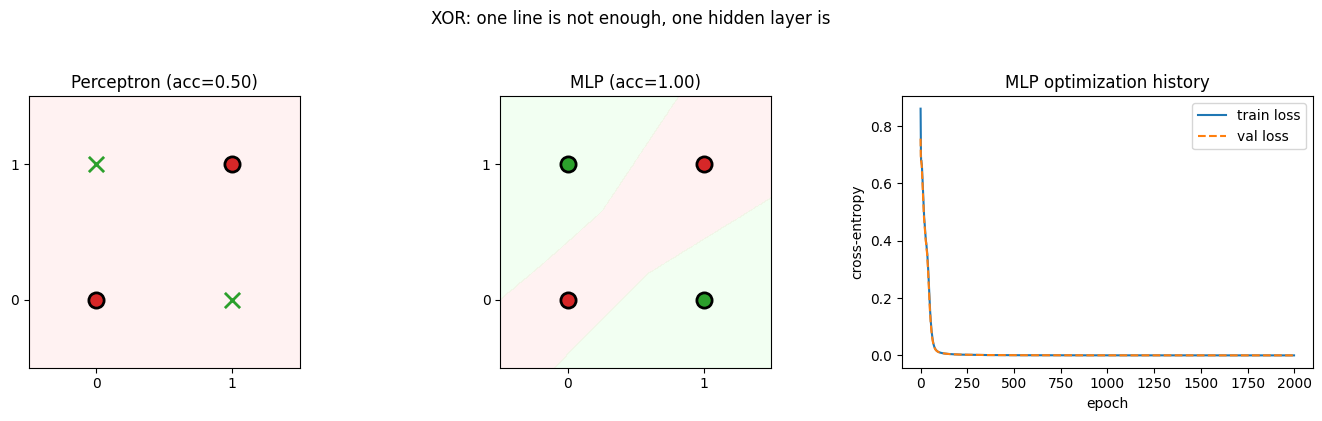

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# XOR data in {0, 1}^2
X = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]], dtype=float)
y = np.array([0, 1, 1, 0], dtype=int)
print("target:", y.tolist())

# A perceptron expects labels in {-1, +1}.
y_pm1 = np.where(y == 1, 1, -1)

# Train a single perceptron: it cannot solve XOR.
perc = Perceptron(in_dim=2, lr=0.2, random_state=0)
_ = perc.fit(X, y_pm1, epochs=200)
pred_perc_pm1 = perc.predict(X)
pred_perc = ((pred_perc_pm1 + 1) // 2).astype(int)
print("Perceptron XOR preds:", pred_perc.tolist())

# Train a small MLP: one hidden layer is already enough.
train_ds = NPDataset(X, y)
train_dl = NPLoader(train_ds, batch_size=4, shuffle=True, seed=0)

mlp = MLP(2, 2, hidden_sizes=[8], activation='relu', seed=0)
history = train_model(mlp, train_dl, train_dl, task='clf', epochs=2000, lr=0.05, verbose=False)
logits, _ = mlp.forward(X, cache=False)
preds_mlp = logits.argmax(axis=1)
print("MLP XOR preds:", preds_mlp.tolist(), "| params:", count_params(mlp))

def plot_xor_perc_vs_mlp_numpy(perc, mlp, history, X, y):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 400), np.linspace(-0.5, 1.5, 400))
    grid = np.c_[xx.ravel(), yy.ravel()]

    z_perc = perc.predict(grid).reshape(xx.shape)
    logits_grid, _ = mlp.forward(grid, cache=False)
    z_mlp = logits_grid.argmax(axis=1).reshape(xx.shape)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

    ax = axes[0]
    ax.contourf(xx, yy, z_perc, levels=[-np.inf, 0, np.inf], alpha=0.25, colors=['#ffcccc', '#ccffcc'])
    w, b = perc.w, perc.b
    if abs(w[1]) > 1e-12:
        xs = np.linspace(-0.5, 1.5, 200)
        ys = -(w[0] * xs + b) / w[1]
        ax.plot(xs, ys, 'k--', lw=2)
    elif abs(w[0]) > 1e-12:
        ax.axvline(-b / w[0], color='k', ls='--', lw=2)

    preds_perc = ((perc.predict(X) + 1) // 2).astype(int)
    for (x1, x2), yi, pi in zip(X, y, preds_perc):
        ax.scatter(x1, x2, c='tab:green' if yi == 1 else 'tab:red', s=120, marker='o' if yi == pi else 'x', edgecolors='k', linewidths=2)
    ax.set_title(f'Perceptron (acc={(preds_perc == y).mean():.2f})')
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_aspect('equal')

    ax = axes[1]
    ax.contourf(xx, yy, z_mlp, levels=[-0.5, 0.5, 1.5], alpha=0.25, colors=['#ffcccc', '#ccffcc'])
    preds_mlp_local, _ = mlp.forward(X, cache=False)
    preds_mlp_local = preds_mlp_local.argmax(axis=1)
    for (x1, x2), yi, pi in zip(X, y, preds_mlp_local):
        ax.scatter(x1, x2, c='tab:green' if yi == 1 else 'tab:red', s=120, marker='o' if yi == pi else 'x', edgecolors='k', linewidths=2)
    ax.set_title(f'MLP (acc={(preds_mlp_local == y).mean():.2f})')
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_aspect('equal')

    ax = axes[2]
    ax.plot(history['train_loss'], label='train loss')
    ax.plot(history['val_loss'], label='val loss', linestyle='--')
    ax.set_xlabel('epoch')
    ax.set_ylabel('cross-entropy')
    ax.set_title('MLP optimization history')
    ax.legend(frameon=True)

    fig.suptitle('XOR: one line is not enough, one hidden layer is', y=1.04)
    plt.tight_layout()
    plt.show()

plot_xor_perc_vs_mlp_numpy(perc, mlp, history, X, y)

## Universal Approximation

The XOR example shows that one hidden layer can already create nonlinear decision boundaries. A broader mathematical statement goes much further: under mild conditions, a feedforward network with a single hidden layer and enough width can approximate any continuous function on a compact domain arbitrarily well.

That theorem should be read carefully. It is an existence result, not a promise that small networks train easily, that one width works for every target, or that approximation is equally efficient for every function.

A useful numerical way to see the idea is to keep the depth fixed at one hidden layer and increase only the width. If the network family is expressive enough, wider models should fit richer one-dimensional target functions more accurately.

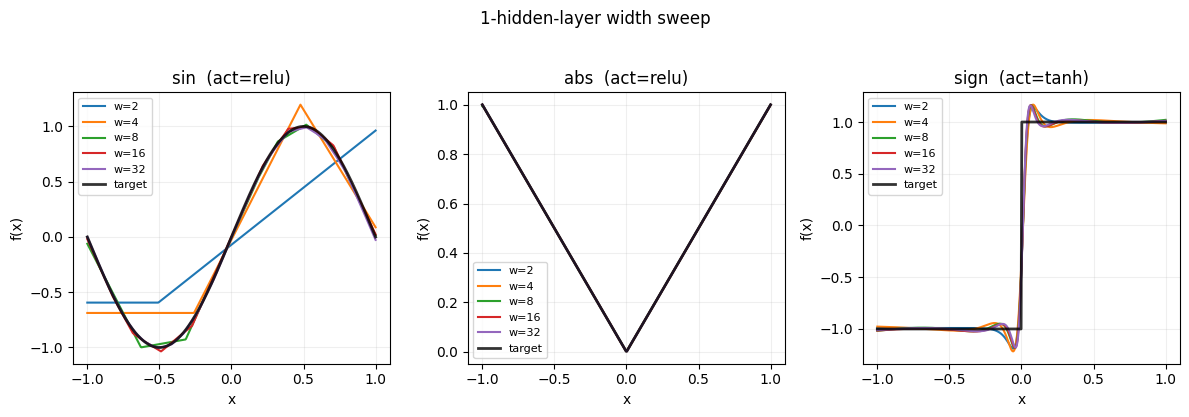

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def make_regression_1d_np(n=256, target='sin', noise=0.0, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1, 1, size=(n,1))
    if target == 'sin':
        y = np.sin(np.pi * x)
    elif target == 'abs':
        y = np.abs(x)
    elif target == 'sign':
        y = np.sign(x)
    else:
        raise ValueError("target must be 'sin' | 'abs' | 'sign'")
    y = y + noise * rng.normal(size=y.shape)
    return x, y

def plot_width_sweep_subplots(widths=(2,4,8,16,32), show_points=False):
    # per-target settings (you can tweak)
    epochs_map = {'sin': 2000, 'abs': 2000, 'sign': 3000}
    lr_map     = {'sin': 1e-2,  'abs': 1e-2,  'sign': 5e-3}
    act_map    = {'sin': 'relu','abs': 'relu','sign': 'tanh'}

    targets = ['sin','abs','sign']
    xs = np.linspace(-1, 1, 400)[:, None]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=False, sharey=False)

    for ax, tgt in zip(axes, targets):
        # data & loaders
        xtr, ytr = make_regression_1d_np(n=256, target=tgt, seed=0)
        xva, yva = make_regression_1d_np(n=256, target=tgt, seed=1)
        train_loader = NPLoader(NPDataset(xtr, ytr), batch_size=64, shuffle=True,  seed=0)
        val_loader   = NPLoader(NPDataset(xva, yva), batch_size=256, shuffle=False, seed=1)

        if show_points:
            ax.scatter(xtr[:,0], ytr[:,0], s=8, alpha=0.25, label='train')

        # width sweep
        for m in widths:
            net = MLP(1, 1, hidden_sizes=[m], activation=act_map[tgt], seed=0)
            _ = train_model(net, train_loader, val_loader,
                            task='reg', epochs=epochs_map[tgt], lr=lr_map[tgt], verbose=False)
            yh, _ = net.forward(xs, cache=False)
            ax.plot(xs, yh, label=f'w={m}')

        # ground truth
        if tgt == 'sin':
            gt = np.sin(np.pi*xs)
        elif tgt == 'abs':
            gt = np.abs(xs)
        else:
            gt = np.sign(xs)
        ax.plot(xs, gt, 'k', lw=2, alpha=0.8, label='target')

        ax.set_title(f"{tgt}  (act={act_map[tgt]})")
        ax.set_xlabel('x'); ax.set_ylabel('f(x)')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8, loc='best')

    fig.suptitle('1-hidden-layer width sweep', y=1.03)
    plt.tight_layout()
    plt.show()

# Run
plot_width_sweep_subplots(widths=(2,4,8,16,32), show_points=False)

## Further Reading

- F. Rosenblatt, Principles of Neurodynamics, 1962, for the original perceptron viewpoint.
- M. Minsky and S. Papert, Perceptrons, 1969, for the classical analysis of linear-threshold limitations.
- D. E. Rumelhart, G. E. Hinton, and R. J. Williams, 1986, for the modern backpropagation formulation.
- G. Cybenko, 1989, and K. Hornik, 1991, for classic universal approximation theorems.
- X. Glorot and Y. Bengio, 2010, and K. He et al., 2015, for practical initialization ideas in deep feedforward networks.
- D. P. Kingma and J. Ba, Adam: A Method for Stochastic Optimization, 2015, for the optimizer used here.